In [ ]:
import os
import glob
import warnings
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import scipy.stats as stats
from sklearn.model_selection import KFold
from tqdm import tqdm

from utils.stats_perform import *
import utils.model_fitting as fit
from utils.data import *
from utils.plots import *
from utils.path import PathConfig,FigureWithData
from rl.models import Tonic_DA_model
from rl.agent import *
from rl.tasks import *

seed_value =0
np.random.seed(seed_value)
random.seed(seed_value)
warnings.filterwarnings("ignore")

fig_dir = os.path.join('figures', 'figure_S2')
data_fig_dir = os.path.join('data', 'source_data', 'figure_S2')
os.makedirs(fig_dir, exist_ok=True)
os.makedirs(data_fig_dir, exist_ok=True)

## Fit RL models to behavior

This notebook performs fits of RL models to the behavioral anticipatory licking responses from the Habenula lesion dataset  

The code below fits 3 different RL models to the licking data on a trial by trial basis: 

**Symmetric** :

$V \leftarrow V + \alpha \cdot \delta \\$ 
$\delta = r - V\\$
$\text{licks} = \beta \cdot V$

parameters: $\theta = \{\beta, \alpha \}$

**Reward sensitivity** 

$V \leftarrow V + \alpha \cdot \delta \\$ 
$\delta =\rho \cdot r - V\\$
$\text{licks} = \beta \cdot V$

parameters: $\theta = \{\beta, \alpha, \rho\}$

**Asymmetric** 

$V \leftarrow V + \tau \cdot \delta ~~~~~ \text{if} ~\delta>0\\$ 
$V \leftarrow V +(1-\tau) \cdot \delta ~~~~~ \text{if} ~\delta<0\\$ 
$\delta =r - V\\$
$\text{licks} = \beta \cdot V$

parameters: $\theta = \{\beta, \tau\}$

**Note**:To plot and use the present notebook the user needs to download the data inside `raw_data` folder of the OSF repository. Look at  `download_data` for the code to do this.

In [8]:
# Sandra Romero Pinto 2022, based  on Sam Gershman, June 2015
paths = PathConfig()
save_dir = paths.save_dir
g_dir = paths.g_dir
suffs = ['control','lesion']
tr_win = [500, 2000]
psth_resolution = 10
e_values =  [.9,.5,.1,-.8]
map_= [0,0,1,1,2,2,3,3]
psth_length = np.intp( 1 + np.ceil((tr_win[1] - tr_win[0]) / psth_resolution) )
alpha_p = .05
mice_v,mice_all,dates_all, id_unique_,u_dates_ = get_mice_dates_list(g_dir,suffs)
u_max = np.max([len(ii) for ii in id_unique_])


In [9]:
models = ['symmetric','reward_sensitivity', 'asymmetric']
results_groups = dict(zip(suffs,[dict() for i in range(len(suffs))]))
id_sim_ = []
for suffix , i_suff in zip(suffs, range(len(suffs))):
    for model in models:
        results_groups[suffix][model]=[]        
        data_path = os.path.join(g_dir,'raw_data',  suffix)
        ff = glob.glob(data_path + "/*.pickle")
        id_unique = id_unique_[i_suff]
        id_sim = []
        print('RL Fitting for group ' + suffix + '|| Model ' + model )
        for iff in tqdm(np.arange(len(id_unique)),'subject:'):
            idu = id_unique[iff]
            with open(ff[idu], 'rb') as handle:
                unit = pickle.load(handle)
            trial_types = unit['data']['TrialTypes']
            licks =  unit['data']['responses']['lick']
            odor_on = unit['data']['events']['odorOn']
            rew_on = unit['data']['events']['rewardOn']
            puff_on = unit['data']['events']['airpuffOn']
            rew_types = map_rewards(rew_on, puff_on,trial_types)
            cue_types = map_cues(map_,trial_types)
            lick_mu , ids_keep = load_lick_raster(licks,odor_on,trial_types,tr_win,psth_resolution,psth_length)
            cue_types = cue_types[ids_keep]
            rew_types = rew_types[ids_keep]
            if np.sum(lick_mu)>0:
                lick_mu = lick_mu[np.arange(len(ids_keep))]
                ids_keep = np.arange(len(ids_keep))
                train, test = KFold(n_splits=2).split(ids_keep)
                id_train, id_test = train[1], train[0]

                data  = dict()
                data['N'] = len(id_train)
                data['c'] = cue_types[id_train]
                data['r'] = rew_types[id_train]
                data['v'] = lick_mu[id_train]
                data['trial'] = np.arange(len(id_train))
                data['v0'] = e_values

                data_test  = dict()
                data_test['N'] = len(id_test)
                data_test['c'] = cue_types[id_test]
                data_test['r'] = rew_types[id_test]
                data_test['v'] = lick_mu[id_test]
                data_test['trial'] = np.arange(len(id_test))
                data_test['v0'] = e_values

                param = fit.create_param_opt(model)
                _llfun = fit.likfun
                results = fit.rlfit_optimize(_llfun, param, data, nstarts=10)
                xx = results['x']
                lf, yhat = fit.likfun_full(xx,data_test,model)
                results['y_test'] = data_test['v']
                results['c_test'] = data_test['c']
                results['r_test'] = data_test['r']
                results['y_hat'] = yhat
                results['corr_pred'] = np.corrcoef(yhat,data_test['v'])[0,1]

                log_p_predict = fit.rlfit_predict(data_test,results,model)
                results['log_predictive_prob'] = log_p_predict
                results_groups[suffix][model].append(results)
                id_sim.append(id_unique[iff])
        id_sim_.append(id_sim)

# Fill in full arrays
results_groups_full = dict(zip(suffs,[dict() for i in range(len(suffs))]))
for suffix , i_suff in zip(suffs, range(len(suffs))):
    dates_full = dates_all[i_suff]
    results_groups_full[suffix] = dict(zip(models,[dict() for i in range(len(models))]))
    for model in models:
        results = results_groups[suffix][model]
        results_groups_full[suffix][model] = [[]]*len(dates_full)
        for (iu,ir) in  enumerate(results):
            date_ = u_dates_[i_suff][iu]
            id_fill = np.argwhere([str(id)==date_ for id in dates_full]).flatten()
            for ii in id_fill:
                results_groups_full[suffix][model][ii] = ir


RL Fitting for group control|| Model symmetric


subject:: 100%|██████████| 35/35 [00:12<00:00,  2.88it/s]


RL Fitting for group control|| Model reward_sensitivity


subject:: 100%|██████████| 35/35 [00:36<00:00,  1.04s/it]


RL Fitting for group control|| Model asymmetric


...

subject:: 100%|██████████| 30/30 [00:12<00:00,  2.36it/s]


RL Fitting for group lesion|| Model reward_sensitivity


subject:: 100%|██████████| 30/30 [00:15<00:00,  1.99it/s]


RL Fitting for group lesion|| Model asymmetric


subject:: 100%|██████████| 30/30 [00:15<00:00,  1.98it/s]


##  Supplementary Figure 2
**Plot of parameter distributions per session**

- N sessions control = 33
- N sessions lesions = 30
  

Perform statistical test for 1. normality, 2. difference in distributions between groups

The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis can be rejected: not drawn from a normal distribution
Saved figure to figures/figure_S2/figure_S2A_symmetric.pdf
Saved data and stats to data/figure_data/figure_S2/figure_S2A_symmetric.txt
The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis can be rejected: not drawn from a normal distribution
Saved figure to figures/figure_S2/figure_S2B_reward_sensitivity.pdf
Saved data and stats to data/figure_data/figure_S2/figure_S2B_reward_sensitivity.txt
The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis can be rejected: not drawn from a normal distribution
Saved figure to figures/figure_S2/figure_S2C_asymmetric.pdf
Saved data and stats to data/figure_data/figure_S2/figure_S2

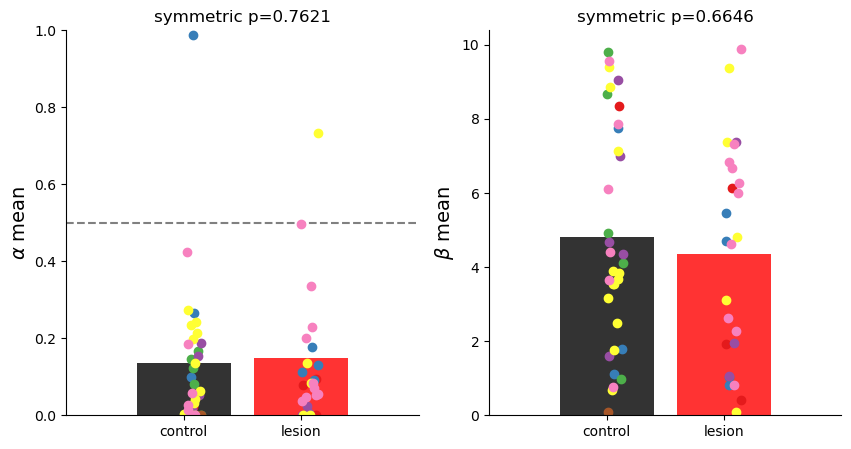

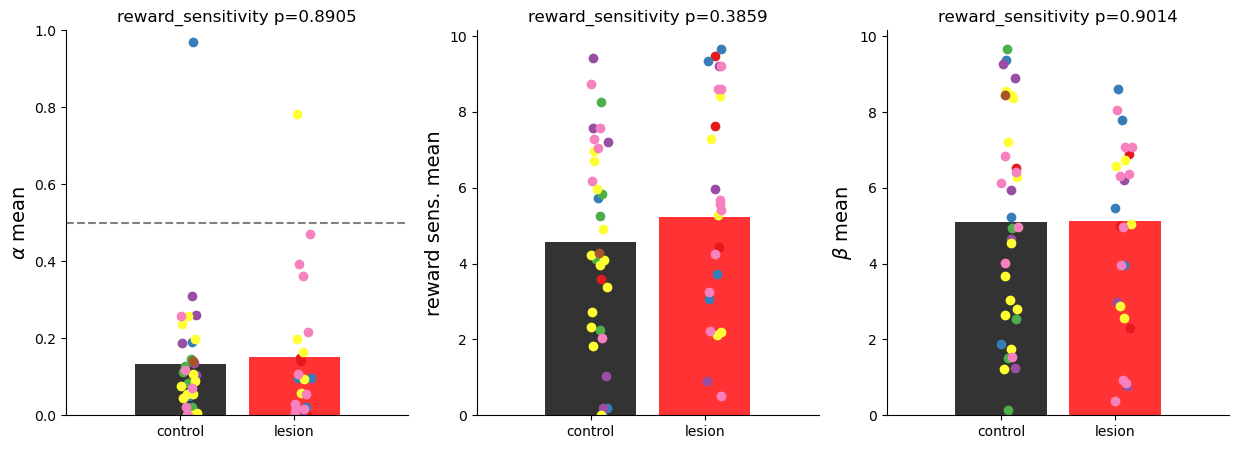

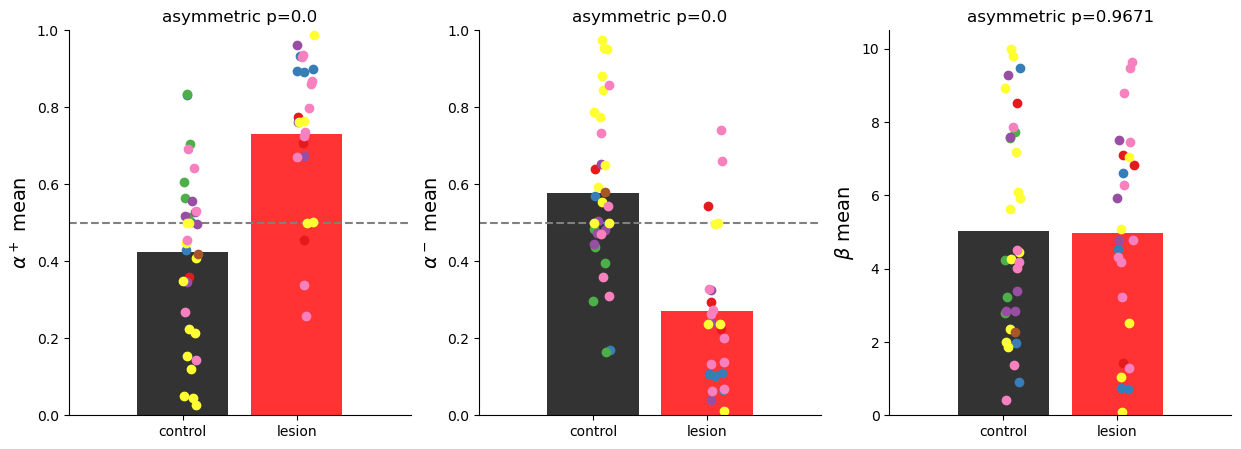

In [12]:
np.random.seed(seed_value)

ylims_ = [[0.,1.],[0,2.],[0.,1.]]
cg = ['black','red']
param_names =[[r'$\alpha$',r'$\beta$'],[r'$\alpha$','reward sens.',r'$\beta$'],[r'$\alpha^+$',  r'$\alpha^-$',r'$\beta$']]
param_suff =[['alpha','beta'],['alpha','reward sens.','beta'],['alpha_pos',  'alpha_neg','beta']]
panels = ['A','B','C']
for (imod,model) in enumerate(models):
    params,params_m = [],[]    
    param_name = param_names[imod]
    for suffix , i_suff in zip(suffs, range(len(suffs))):
        params_ = []
        n_sessions = len( results_groups[suffix][model])
        id_unique,id_sim = id_unique_[i_suff],id_sim_[i_suff]
        ids = np.argwhere([sum(id_sim==iu) for iu in id_unique]).flatten()
        mice_ = mice_v[i_suff][ids]
        for iff in np.arange(n_sessions):
            if model =='asymmetric':
                x_ = results_groups[suffix][model][iff]['x']
                taus_ = x_[0]/(x_[0]+x_[1])
                params_.append(np.asarray([taus_,1-taus_,x_[2]]))
            else:
                params_.append(results_groups[suffix][model][iff]['x'])
        params_ = np.asarray(params_)
        params_per_m = [np.array([params_[ii] for ii in np.argwhere(mice_==im)]).squeeze() for im in np.unique(mice_)]
        nsess = np.asarray([len(np.argwhere(mice_==im)) for im in np.unique(mice_)])
        params_corr = [ip[np.newaxis,:] for ip in params_per_m if len(ip.shape)==1 ]
        for (iid,ii) in enumerate(np.argwhere(nsess==1).flatten()):
            params_per_m[ii] = params_corr[iid]
        params.append(params_)
        params_m.append(params_per_m)
    n_params = params[0].shape[1]

    groups_test = [[params[0][:,jj],params[1][:,jj]]  for jj in np.arange(n_params)]
    name_suff = param_suff[imod]
    name_preff = model
    if imod ==0:
        tests_pd = get_tests_table(groups_test, name_preff, name_suff,restart_pd = True,alpha_p=alpha_p)
    else:
        tests_pd = get_tests_table(groups_test, name_preff, name_suff,restart_pd = False, tests_pd=tests_pd,alpha_p=alpha_p)
    pvals_norm = np.asarray([tests_pd[(tests_pd['name_test'] == 'normaltest') & (tests_pd['group_name'] == model + '_all')].pvals.to_numpy()[0]  ])
    
    ll = len(tests_pd[(tests_pd['name_test'] == 'normaltest') & (tests_pd['group_name'] == model+'_all' )].pvals.to_numpy()[0])
    ss = np.sum(tests_pd[(tests_pd['name_test'] == 'normaltest') & (tests_pd['group_name'] == model+'_all' )].pvals.to_numpy()[0]>.05)
    if ll>ss:
        st = np.asarray([tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_name'] == model + '_'+ isuff)].pvals.to_numpy()[0] for isuff in name_suff])
    else:
        st = np.asarray([tests_pd[(tests_pd['name_test'] == 'ttest') & (tests_pd['group_name'] == model + '_'+ isuff)].pvals.to_numpy()[0] for isuff in name_suff])
    if np.sum(pvals_norm<alpha_p) ==2:
        mus_ = np.asarray([np.nanmedian(x[:,ii]) for x in params for ii in np.arange(n_params)])
        ylab = 'median'
    else:
        mus_ = np.asarray([np.nanmean(x[:,ii]) for x in params for ii in np.arange(n_params)])
        ylab = 'mean'

    fix,ax  = plt.subplots(1,n_params,figsize=(5*n_params,5))    
    if n_params==1:  ax = np.asarray(ax)[...,np.newaxis]
    id_lims = ['alpha' in ip for ip in param_name]
    [ax[ii].plot([-1,2],[.5,.5],color='grey',linestyle='--') for ii in np.argwhere(id_lims).flatten()]
    [ax[ii].bar(np.arange(2),mus_[np.arange(ii,len(mus_),step=n_params)],color=cg,alpha=.8) for ii in np.arange(n_params)]
    [[[ax[ii].plot(ix+.15*np.random.rand(len(np.asarray(iparamsuff[im])[:,ii])),np.asarray(iparamsuff[im])[:,ii],'o',color=cm.Set1(im/len(iparamsuff))) for ii in range(n_params)] for im in range(len(iparamsuff))] for  (ix,iparamsuff) in enumerate(params_m)] 
    [plot_config(ax[ii],'',param_name[ii] + ' '+ylab,14,False) for ii in np.arange(n_params)]
    [ax[ii].set_xlim(([-1,2])) for ii in np.arange(n_params)]
    [ax[ii].set_ylim([0.,1.]) for ii in np.argwhere(id_lims).flatten()]
    [ax[ii].set_xticks([0,1]) for ii in np.arange(n_params)]
    [ax[ii].set_xticklabels(suffs) for ii in np.arange(n_params)]
    [ax[ii].set_title(model+' p='+str(np.round(st[ii]*10000)/10000)) for ii in np.arange(n_params)]

    param_suff_model = param_suff[imod]
    n_params = len(param_name)
    fig_data_model = FigureWithData(fix)  # <-- fix is the figure handle from your plotting code
    # Save per parameter
    for ii in range(n_params):
        # 1. Save bar means/medians
        bar_values = mus_[np.arange(ii, len(mus_), step=n_params)]
        bar_array = np.column_stack((
            np.arange(2),  # 0: Control, 1: Learning
            bar_values
        ))
        bar_headers = ['Group_index', f'{param_name[ii]}_{ylab}']

        fig_data_model.add_data(
            f"Bar values for {param_name[ii]}",
            bar_array,
            bar_headers
        )

        # 2. Save individual mouse dots
        dots_control = np.concatenate(params_m[0])[:, ii]
        dots_learning = np.concatenate(params_m[1])[:, ii]

        max_len = max(len(dots_control), len(dots_learning))
        dots_array = np.full((max_len, 2), np.nan)
        dots_array[:len(dots_control), 0] = dots_control
        dots_array[:len(dots_learning), 1] = dots_learning

        fig_data_model.add_data(
            f"Individual mouse values for {param_name[ii]}",
            dots_array,
            ['Control', 'Learning']
        )

        # 3. Save p-value/statistic
        stat_array = np.array([[st[ii]]])
        stat_headers = ['p_value']

        fig_data_model.add_stats(
            f"Statistical test for {param_name[ii]}",
            stat_array,
            stat_headers
        )
    # 4. Save everything
    fig_data_model.save(
        base_filename=f'figure_S2{panels[imod]}_{model.lower()}',
        folder_data= data_fig_dir,
        folder_figures= fig_dir
    )
tests_pd.to_excel("analysis/stats/Supp_Fig2.xlsx")  


**Plot of parameter distributions per mouse**

- N mice control = 6
- N mice lesions = 5


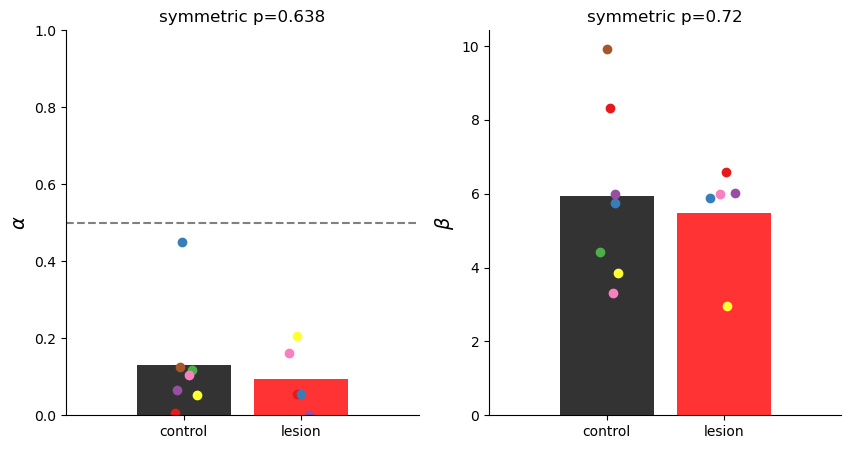

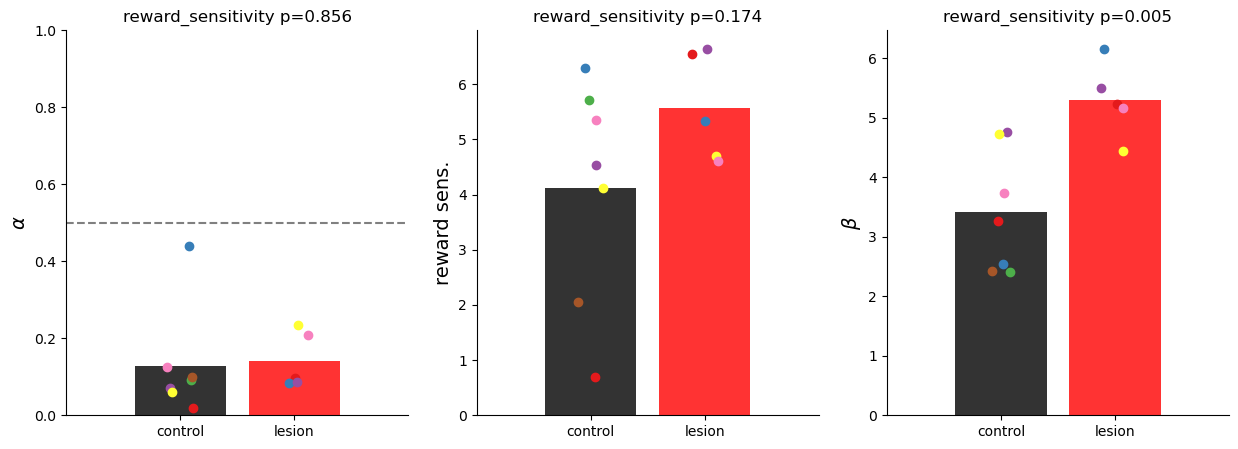

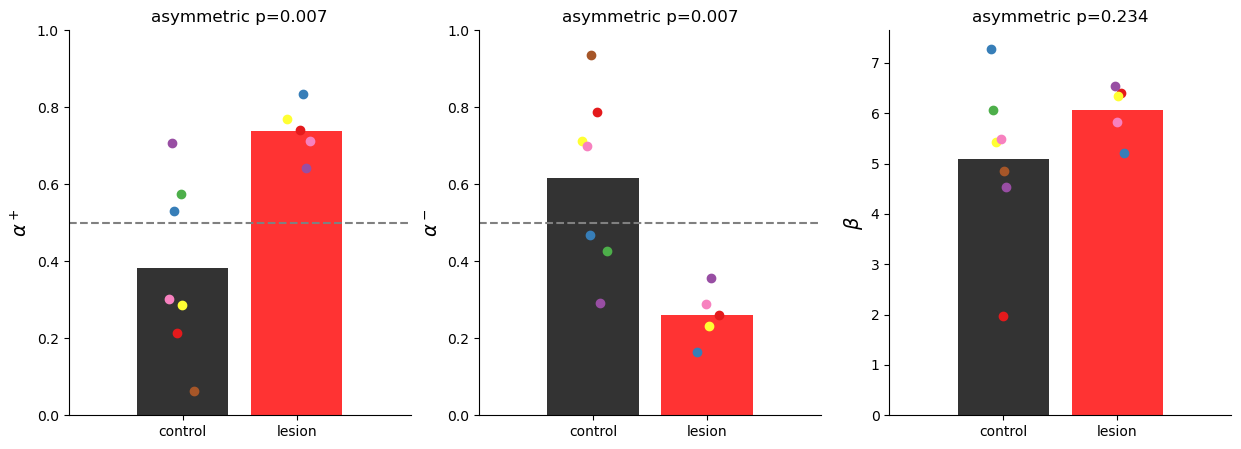

In [11]:
np.random.seed(seed_value)
ylims_ = [[0.,1.],[0,2.],[0.,1.]]
cg = ['black','red']
param_names =[[r'$\alpha$',r'$\beta$'],[r'$\alpha$','reward sens.',r'$\beta$'],[r'$\alpha^+$',  r'$\alpha^-$',r'$\beta$']]
alpha_p = .05
for model, imod in zip(models,range(len(models))):
    params = [];    
    param_name = param_names[imod]
    for suffix , i_suff in zip(suffs, range(len(suffs))):
        params_ = []
        n_sessions = len(results_groups[suffix][model])
        id_unique,id_sim = id_unique_[i_suff],id_sim_[i_suff]
        ids = np.argwhere([sum(id_sim==iu) for iu in id_unique]).flatten()
        mice_ = mice_v[i_suff][ids]
        for iff in np.arange(n_sessions):
            if model =='asymmetric':
                x_ = results_groups[suffix][model][iff]['x']
                taus_ = x_[0]/(x_[0]+x_[1])
                params_.append(np.asarray([taus_,1-taus_,x_[2]]))
            else:
                params_.append(results_groups[suffix][model][iff]['x'])
        params_ = np.asarray(params_)
        params_per_m = [[params_[ii] for ii in np.argwhere(mice_==im)] for im in np.unique(mice_)]
        params.append(params_per_m)

    n_params = params[0][0][0].shape[1]
    stds_ = [[np.nanstd(np.asarray(iparamsuff[im]),axis=0)/np.sqrt(len(np.asarray(iparamsuff[im]))) for im in range(len(iparamsuff))] for iparamsuff in params]
    mus_ = [[np.nanmean(np.asarray(iparamsuff[im]),axis=0) for im in range(len(iparamsuff))] for iparamsuff in params]
    mus_mice = np.asarray([np.nanmean(np.asarray(imusuff),axis=0) for imusuff in mus_]).squeeze()

    st = [stats.ttest_ind(np.asarray(mus_[0]).squeeze()[:,jj],np.asarray(mus_[1]).squeeze()[:,jj]).pvalue  for jj in np.arange(n_params)]

    fix,ax  = plt.subplots(1,n_params,figsize=(5*n_params,5))    
    if n_params==1:  ax = np.asarray(ax)[...,np.newaxis]
    id_lims = ['alpha' in ip for ip in param_name]
    [ax[ii].plot([-1,2],[.5,.5],color='grey',linestyle='--') for ii in np.argwhere(id_lims).flatten()]
    [ax[ii].bar(np.arange(2),mus_mice[:,ii],color=cg,alpha=.8) for ii in np.arange(n_params)]
    [[[ax[ii].plot(isuff+(np.random.rand()-.5)*.25,mus_[isuff][im].flatten()[ii],'o',color=cm.Set1(im/len(mus_[isuff]))) for ii in range(n_params)] for im in range(len(mus_[isuff])) ] for isuff in range(len(mus_))] 
    # [[[ax[ii].errorbar(isuff+(np.random.rand()-.5)*.5,mus_[isuff][im].flatten()[ii],stds_[isuff][im].flatten()[ii],color=cm.Set1(im/len(mus_[isuff]))) for ii in range(n_params)] for im in range(len(mus_[isuff])) ] for isuff in range(len(mus_))] 
    [plot_config(ax[ii],'',param_name[ii],14,False) for ii in np.arange(n_params)]
    [ax[ii].set_xlim(([-1,2])) for ii in np.arange(n_params)]
    [ax[ii].set_ylim([0.,1.]) for ii in np.argwhere(id_lims).flatten()]
    [ax[ii].set_xticks([0,1]) for ii in np.arange(n_params)]
    [ax[ii].set_xticklabels(suffs) for ii in np.arange(n_params)]
    [ax[ii].set_title(model+ ' p='+str(np.round(st[ii]*1000)/1000)) for ii in np.arange(n_params)]


prob = 0.1
prob = 0.5
prob = 0.9


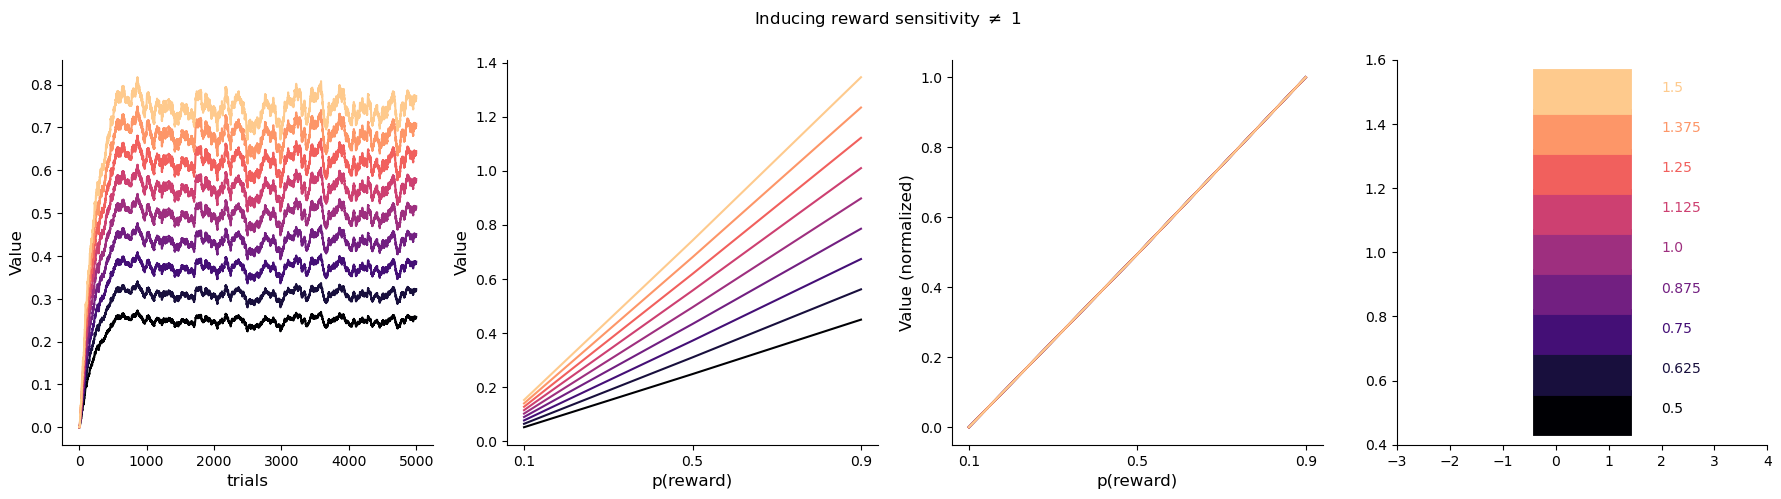

In [38]:


# Learning rule of av. rewad 
ntrials = 5000
probs = np.array([.1,.5,.9])
beta = 0.000001
step_size = .01
eta = 0.1
tau = 0.5
rew_sensitivities =np.linspace(.5,1.5,9)
vv, rpev = np.zeros((len(probs),len(rew_sensitivities),ntrials)),np.zeros((len(probs),len(rew_sensitivities),ntrials))
nv, pv = np.zeros((len(probs),len(rew_sensitivities),ntrials)),np.zeros((len(probs),len(rew_sensitivities),ntrials))


for (ipr,pr) in  enumerate(probs):
    print('prob = '+str(pr))
    s  = {'task':{}}
    s['task']['prob']  = [[1-pr,pr],[1-pr,pr]]
    s['task']['mags'] = [[0,1],[0,1]]
    s['task']['cs_id'] = [[0,0],[1,1]]
    s['task']['percent_per_cs']  =np.array([.5,.5])[:,None]
    s['task']['str_cs'] = ['50%']
    s['task']['str_task'] = 'Cue_Rew_RW'
    s['task']['n_trials'] = ntrials
    s['task']['cue_onset']  = 1
    s['task']['cue_dur']  = 1
    s['task']['rew_onset']  = 4
    s['task']['iti_dur']  = 5
    s['task']['seed'] = seed_value
    task  = TaskCueReward(s)
    us_vector, cs_vector = task.create_csus_vectors()

    for (irs,irew_sens) in enumerate(rew_sensitivities):
        vv[ipr,irs,0], nv[ipr,irs,0], pv[ipr,irs,0] = 0,0,0
        for itr in range(1,ntrials):
            pi = pv[ipr,irs,itr-1]
            ni = nv[ipr,irs,itr-1]
            us = us_vector[itr]
            rpe = irew_sens*us - (pi - ni)
            pi += step_size*(tau*np.abs(rpe)*(rpe>=0))- beta*pi
            ni += step_size*((1-tau)*np.abs(rpe)*(rpe<=0))-  beta*ni

            nv[ipr,irs,itr], pv[ipr,irs,itr] = ni, pi
            rpev[ipr,irs,itr],  vv[ipr,irs,itr] = rpe,pi-ni


fig,ax = plt.subplots(1,4,figsize=(22,5))
_ = [ax[0].plot(vv[1,it,:],color=cm.magma(it/len(rew_sensitivities))) for it in range(len(rew_sensitivities))]
_ = [ax[1].plot(probs,np.nanmean(vv[:,it,-1000:],axis=1).T,color=cm.magma(it/len(rew_sensitivities))) for it in range(len(rew_sensitivities))]
_ = [ax[2].plot(probs,(np.nanmean(vv[:,it,-1000:],axis=1).T-np.nanmean(vv[0,it,-1000:]).T)/(np.nanmean(vv[-1,it,-1000:]).T-np.nanmean(vv[0,it,-1000:]).T),color=cm.magma(it/len(rew_sensitivities))) for it in range(len(rew_sensitivities))]

_ = [ax[3].plot([0,1],[irew_sens,irew_sens],color =cm.magma(it/len(rew_sensitivities)),lw=33) for (it,irew_sens) in enumerate(rew_sensitivities)]
_ = [ax[3].text(2,irew_sens,str(irew_sens),color =cm.magma(it/len(rew_sensitivities))) for (it,irew_sens) in enumerate(rew_sensitivities)]
ax[3].set_xlim([-3,4])
ax[3].set_ylim([.4 ,1.6])
plot_config(ax[0],'trials','Value',12,False)
plot_config(ax[1],'p(reward)','Value',12,False)
plot_config(ax[2],'p(reward)','Value (normalized)',12,False)
plot_config(ax[3],'','',12,False)
ax[1].set_xticks(probs)
ax[2].set_xticks(probs)
plt.suptitle(r'Inducing reward sensitivity $\neq$ 1')
plt.savefig('reward_sensitivity_induction.pdf')